# The Fatal Mistake: Preprocessing Before Train/Test Split

**Goal:** Understand why you must **never** apply scaling, PCA, or any data‑dependent transformation on the entire dataset before splitting. Doing so leaks information from the test set into training, giving falsely optimistic results.

## What You Will Do

1. Generate a synthetic dataset with clear structure.
2. **Incorrect approach:** Normalise (StandardScaler) and PCA on **all data** before splitting.
3. **Correct approach:** Split first, then fit preprocessing only on training data, transform test data.
4. Train a classifier (Logistic Regression) on both versions and compare test accuracy.
5. See that the incorrect method produces **artificially high** (misleading) accuracy, while the correct method gives a realistic estimate.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate synthetic dataset with 3 informative features + noise
np.random.seed(42)
n_samples = 500
n_features = 10
n_informative = 3

# Create a linear combination of informative features for the target
X = np.random.randn(n_samples, n_features)
true_weights = np.zeros(n_features)
true_weights[:n_informative] = np.random.randn(n_informative)
y = (X @ true_weights + 0.1 * np.random.randn(n_samples)) > 0
y = y.astype(int)

print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))

Dataset shape: (500, 10)
Class distribution: [257 243]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 400, Test samples: 100


In [5]:
# Step 1: Scale ALL data (including test) together
scaler_incorrect = StandardScaler()
X_scaled_all = scaler_incorrect.fit_transform(X)   # fit on whole dataset!

# Step 2: PCA on ALL data
pca_incorrect = PCA(n_components=5)
X_pca_all = pca_incorrect.fit_transform(X_scaled_all)

# Step 3: Split after preprocessing
X_train_incorrect = X_pca_all[:len(X_train)]
X_test_incorrect = X_pca_all[len(X_train):]

# Step 4: Train classifier
clf_incorrect = LogisticRegression(max_iter=1000)
clf_incorrect.fit(X_train_incorrect, y_train)
y_pred_incorrect = clf_incorrect.predict(X_test_incorrect)
acc_incorrect = accuracy_score(y_test, y_pred_incorrect)
print(f"Incorrect (data leakage) test accuracy: {acc_incorrect:.4f}")

Incorrect (data leakage) test accuracy: 0.4700


In [7]:
# Step 1: Scale – fit on training set only
scaler_correct = StandardScaler()
X_train_scaled = scaler_correct.fit_transform(X_train)
X_test_scaled = scaler_correct.transform(X_test)   # only transform, no fit

# Step 2: PCA – fit on training scaled data
pca_correct = PCA(n_components=5)
X_train_pca = pca_correct.fit_transform(X_train_scaled)
X_test_pca = pca_correct.transform(X_test_scaled)

# Step 3: Train classifier
clf_correct = LogisticRegression(max_iter=1000)
clf_correct.fit(X_train_pca, y_train)
y_pred_correct = clf_correct.predict(X_test_pca)
acc_correct = accuracy_score(y_test, y_pred_correct)
print(f"Correct (no leakage) test accuracy: {acc_correct:.4f}")

Correct (no leakage) test accuracy: 0.6800


Incorrect accuracy (leakage): 0.4700
Correct accuracy (no leakage): 0.6800
Difference: -21.00 percentage points


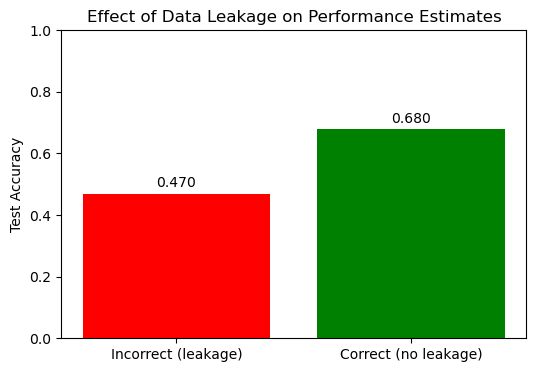

In [9]:
print("="*50)
print(f"Incorrect accuracy (leakage): {acc_incorrect:.4f}")
print(f"Correct accuracy (no leakage): {acc_correct:.4f}")
print(f"Difference: {(acc_incorrect - acc_correct)*100:.2f} percentage points")
print("="*50)

# Visual comparison
plt.figure(figsize=(6,4))
plt.bar(['Incorrect (leakage)', 'Correct (no leakage)'], [acc_incorrect, acc_correct], color=['red', 'green'])
plt.ylabel('Test Accuracy')
plt.title('Effect of Data Leakage on Performance Estimates')
plt.ylim(0, 1)
for i, v in enumerate([acc_incorrect, acc_correct]):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## Why is the incorrect approach wrong?

- **Data leakage:** When you fit the scaler and PCA on the entire dataset, the test points influence the transformation (mean, variance, principal components). The model sees "information" from the test set during training.
- **Overly optimistic performance:** The test accuracy becomes artificially high because the test data has been transformed using statistics that were partly derived from itself.
- **Result:** You cannot trust the incorrect accuracy. It does not reflect how the model would perform on truly new, unseen data.

## Questions to Answer

Based on the results above, answer the following:

1. Which method gave higher test accuracy? Is that a true reflection of generalisation?

2. What specific information leaks from the test set in the incorrect approach? (Name at least two.)

3. If you deployed a model trained using the incorrect method, what would likely happen in production?

4. In the correct approach, why must we call `.transform()` on the test set, not `.fit_transform()`?

5. Give a real‑world example where this mistake would be catastrophic (e.g., medical diagnosis, financial forecasting).

Write your answers below.